# Supplementary Figure 2

*Carvalho, Cojocaru and Fukai (2026)*

**See also:** `figure3_upload.ipynb` (results with `alpha` = 0.0693).

## 📌 User input: start here!

### 1️⃣ Exponential gap penalty

Supplementary figures use `alpha` (allowed spike-time jitter) = 0.1386 (5 ms).

### 2️⃣ Date

This notebook requires the output `run_all.py` and `movement_classes.py`. After verifying that both scripts have run, update the date of the result folder.

### 3️⃣ Raw data path

To perform the normalization necessary to obtain outcome specificity, this notebook also imports the `Event.dat` file from the dataset. Set the path below to where the raw data is stored.

In [ ]:
alpha = "0.1386"
date_str = "20XX-XX-XX"
path_data_root = "/path/to/data/root/"

## Imports

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import graphcheck as gc
from ast import literal_eval

from import_data import import_run_all
from plot_style import *

sessions = ["071102", "071107", "071109", "071213", 
            "071214", "071218", "071221", "071227", 
            "080213", "071228", "080206", "080208", 
            "080227", "080220", "080222"]

file_name = "run_all"
path_local = "../"

path_in = path_local + "results/" + date_str + "/" + file_name + "/"

path_out = path_local + "results/" + date_str + "/paper_plots/"
if not os.path.exists(path_out):
    os.makedirs(path_out)

path_plots = path_out + f"figure3_alpha{alpha}/"
if not os.path.exists(path_plots):
    os.makedirs(path_plots)

path_out_movement = path_local + "results/movement_classes/"

event_file = "Event.dat"
stage_limits = {"Early": (100000, 1300000), "Late": (3600000, 4800000)}     # 20-minute stages in milliseconds

(
    df_stage,
    df_comparison,
    df_neuron_concat,
    df_edge_concat,
    df_profile_concat,
    df_reward_concat_full,
    df_reward_combined_concat_full,
    df_reward_concat_prof_len,
) = import_run_all(
    sessions,
    alpha,
    path_in,
    path_out_movement,
    export=True,
)

## Helpers

In [3]:
def import_event_data(path_event: str, start_time_ms: int, end_time_ms: int, frequency_Hz: int = 20000, norm: bool = True):
    """
    Import event data (adapted from graphcheck/loaddata.py)
    """
    event = gc.open_file(
        path_event, "Event.dat", start_time_ms, end_time_ms,
        frequency_Hz, np.int16, shift=False)
    if norm:
        event[1] = gc.norm_max_abs(event[1])
    return event

## Identify trial outcome via event data

In [4]:
trial_counts = []

for session in sessions:
    for stage in ["Early", "Late"]:
        session_folder_name = session
        event_file_path = os.path.join(path_data_root, session_folder_name)
        event_data = import_event_data(event_file_path, start_time_ms=stage_limits[stage][0], end_time_ms=stage_limits[stage][1])
        times_success, times_failure = gc.calculate_success_failure(event_data)
        trial_counts.append({
            "session": int(session),
            "stage": stage,
            "rewarded_trials": len(times_success),
            "unrewarded_trials": len(times_failure)
        })

df_trial_count = pd.DataFrame(trial_counts)
df_trial_count["session"] = df_trial_count["session"].astype(str)

In [5]:
df_reward_concat_full["Session"] = df_reward_concat_full["Session"].astype(str)

# `simple` dataframe: allows multiple sequences to be aligned to the same trial outcome signal
df_reward_simple = df_reward_concat_full[(df_reward_concat_full["Event"] == "Success_Signal") | (df_reward_concat_full["Event"] == "Failure")].copy()

df_reward_clean = df_reward_simple.copy()

# find the index of the row with the lowest absolute Time Distance (ms)
idx = (
    df_reward_clean
    .groupby(["Session", "Stage", "Profile ID", "Sequence Time (ms)"])["Time Distance (ms)"]
    .apply(lambda x: x.abs().idxmin())
)

# `clean` dataframe: keeps only the sequence that is closest to the trial outcome signal (for each profile and sequence time)
df_reward_clean = df_reward_clean.loc[idx].reset_index(drop=True)

In [6]:
df_prof = df_profile_concat[df_profile_concat["Method"] == "Profile"].copy()
df_prof["Times (ms)"] = df_prof["Times (ms)"].apply(literal_eval)
df_prof["Session"] = df_prof["Session"].astype(str)
df_prof = df_prof.explode('Times (ms)')
df_prof = df_prof.rename(columns={"Times (ms)": "Sequence Time (ms)"})

In [7]:
df_reward_clean = df_reward_clean.merge(
    df_prof, on=["Session", "Stage", "Min Profile Length", "Method", "Profile ID", "Sequence Time (ms)"], how="left"
)

# Trial alignment and outcome specificity

In [8]:
specificity = []

for (session, stage, profile_id, ids), df_local in df_reward_clean.groupby(["Session", "Stage", "Profile ID", "IDs"]):
    df_local_success = df_local[df_local["Event"] == "Success_Signal"].copy()
    df_local_failure = df_local[df_local["Event"] == "Failure"].copy()
    df_local_prof = df_prof[(df_prof["Session"] == session) & (df_prof["Stage"] == stage) & (df_prof["Profile ID"] == profile_id)].copy()

    avg_time_distance = df_local["Time Distance (ms)"].mean()
    std_time_distance = df_local["Time Distance (ms)"].std()

    avg_time_distance_success = df_local_success["Time Distance (ms)"].mean()
    std_time_distance_success = df_local_success["Time Distance (ms)"].std()

    avg_time_distance_failure = df_local_failure["Time Distance (ms)"].mean()
    std_time_distance_failure = df_local_failure["Time Distance (ms)"].std()

    sequence_count = df_local_prof["Sequence count"].iloc[0].astype(int)
    success_count = df_local_success.shape[0]
    failure_count = df_local_failure.shape[0]

    trial_row = df_trial_count[(df_trial_count["session"] == session) & (df_trial_count["stage"] == stage)]
    if trial_row.empty:
        # fallback to 0 if trial counts are missing to avoid index errors
        rewarded_trial_count = 0
        unrewarded_trial_count = 0
    else:
        rewarded_trial_count = int(trial_row["rewarded_trials"].values[0])
        unrewarded_trial_count = int(trial_row["unrewarded_trials"].values[0])

    norm_success_count = success_count / rewarded_trial_count if rewarded_trial_count > 0 else 0
    norm_failure_count = failure_count / unrewarded_trial_count if unrewarded_trial_count > 0 else 0

    if sequence_count > 10:
        specificity.append({
            "Session": session,
            "Stage": stage,
            "Profile ID": profile_id,
            "IDs": ids,
            "Sequence Count": sequence_count,
            "Rewarded Trial Count": rewarded_trial_count,
            "Unrewarded Trial Count": unrewarded_trial_count,
            "Success Count": success_count,
            "Failure Count": failure_count,
            "Norm Success Count": norm_success_count,
            "Norm Failure Count": norm_failure_count,
            "Outcome Specificity": (norm_success_count - norm_failure_count) / (norm_success_count + norm_failure_count) if (norm_success_count + norm_failure_count) > 0 else np.nan,
            "Tone Alignment": (success_count + failure_count) / sequence_count,
            "Avg Distance": avg_time_distance,
            "Std Distance": std_time_distance,
            "Avg Distance Success": avg_time_distance_success,
            "Std Distance Success": std_time_distance_success,
            "Avg Distance Failure": avg_time_distance_failure,
            "Std Distance Failure": std_time_distance_failure,
        })

df_specificity = pd.DataFrame(specificity)
df_specificity.to_csv(path_out + f"AUX_df_specificity_alpha_{alpha}.csv", index=False)

In [9]:
df_specificity_avg = (
    df_specificity
    .groupby(["Session", "Stage"], as_index=False)
    .agg(
        Avg_OS=("Outcome Specificity", "mean"),
        Std_OS=("Outcome Specificity", "std"),
        Avg_TA=("Tone Alignment", "mean"),
        Std_TA=("Tone Alignment", "std"),
        Count=("Profile ID", "count")
    )
)

df_specificity_avg = df_specificity_avg[df_specificity_avg["Count"] >= 5].copy()

In [10]:
num_stages = len(df_specificity_avg)
TA_above_50 = df_specificity_avg[df_specificity_avg["Avg_TA"] > 0.5].copy()
NOS_above_0 = df_specificity_avg[df_specificity_avg["Avg_OS"] > 0].copy()
TA_above_50_NOS_above_0 = df_specificity_avg[(df_specificity_avg["Avg_TA"] > 0.5) & (df_specificity_avg["Avg_OS"] > 0)].copy()

print("=== Stage count summary ===")
print("Total number of stages following required conditions:", num_stages)

print("")
print(len(TA_above_50), "rows with average tone alignment above 0.5")
print(round(len(TA_above_50) / num_stages * 100, 2), "% of stages with average tone alignment above 0.5")

print("")
print(len(NOS_above_0), "rows with average outcome specificity above 0")
print(round(len(NOS_above_0) / num_stages * 100, 2), "% of stages with average outcome specificity above 0")

print("")
print(len(TA_above_50_NOS_above_0), "rows with average tone alignment above 0.5 and average outcome specificity above 0")
print(round(len(TA_above_50_NOS_above_0) / num_stages * 100, 2), "% of stages with average tone alignment above 0.5 and average outcome specificity above 0")

=== Stage count summary ===
Total number of stages following required conditions: 24

17 rows with average tone alignment above 0.5
70.83 % of stages with average tone alignment above 0.5

17 rows with average outcome specificity above 0
70.83 % of stages with average outcome specificity above 0

12 rows with average tone alignment above 0.5 and average outcome specificity above 0
50.0 % of stages with average tone alignment above 0.5 and average outcome specificity above 0


In [11]:
df_specificity_avg_stage = (
    df_specificity
    .groupby(["Stage"], as_index=False)
    .agg(
        Avg_OS=("Outcome Specificity", "mean"),
        Std_OS=("Outcome Specificity", "std"),
        Avg_TA=("Tone Alignment", "mean"),
        Std_TA=("Tone Alignment", "std"),
        Count=("Profile ID", "count")
    )
)

In [12]:
print("=== Grouped by stage summary ===")

print("\nTone alignment (mean ± std):")
print(df_specificity_avg_stage[["Stage", "Avg_TA", "Std_TA"]].round(3))

print("\nOutcome specificity (mean ± std):")
print(df_specificity_avg_stage[["Stage", "Avg_OS", "Std_OS"]].round(3))

=== Grouped by stage summary ===

Tone alignment (mean ± std):
   Stage  Avg_TA  Std_TA
0  Early   0.574   0.220
1   Late   0.508   0.252

Outcome specificity (mean ± std):
   Stage  Avg_OS  Std_OS
0  Early   0.120   0.433
1   Late   0.121   0.443


## Panel B

In [13]:
blue_highlight_stage = ("71102", "Early")
cyan_highlight_stage = ("80213", "Late")
pink_highlight_stage = ("71228", "Late")
orange_highlight_stage = ("80222", "Late")

highlight_stages = [blue_highlight_stage, cyan_highlight_stage, pink_highlight_stage, orange_highlight_stage]

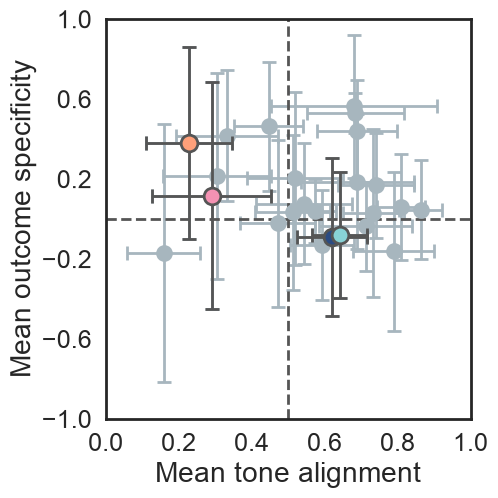

In [14]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

ax.errorbar(df_specificity_avg["Avg_TA"], df_specificity_avg["Avg_OS"], xerr=df_specificity_avg["Std_TA"], yerr=df_specificity_avg["Std_OS"], fmt='o', capsize=5, elinewidth=2, markeredgewidth=2, color=colors['lightgray'], alpha=1)

for i, (session, stage) in enumerate(highlight_stages):
    df_session = df_specificity_avg[(df_specificity_avg["Session"] == session) & (df_specificity_avg["Stage"] == stage)]
    if not df_session.empty:
        ax.errorbar(df_session["Avg_TA"], df_session["Avg_OS"],
                xerr=df_session["Std_TA"], yerr=df_session["Std_OS"],
                fmt='o', capsize=5, elinewidth=2, markeredgewidth=2, markeredgecolor=color_lines, markersize=12,
                color=color_lines, markerfacecolor=palette_methods_4[i], label=f"{session} {stage}", zorder=10)

ax.axhline(0, color=color_lines, linestyle='--', linewidth=2)
ax.axvline(0.5, color=color_lines, linestyle='--', linewidth=2)

ax.set_xlim(0, 1)
ax.set_ylim(-1, 1)
ax.grid(False)

ax.set_xticks(np.arange(0, 1.1, 0.2))
ax.set_yticks(np.arange(-1, 1.1, 0.4))

ax.set_xlabel("Mean tone alignment")
ax.set_ylabel("Mean outcome specificity")

fig.tight_layout()
plt.savefig(path_plots + "reward_specificity_avg.pdf", dpi=300, bbox_inches='tight')


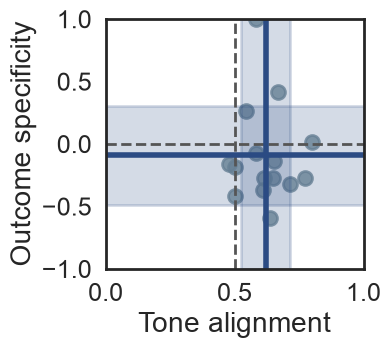

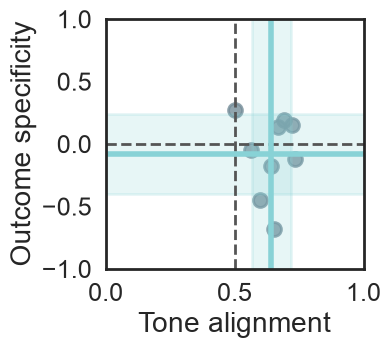

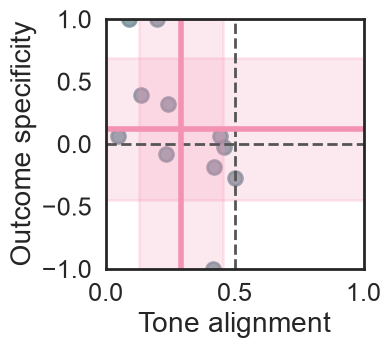

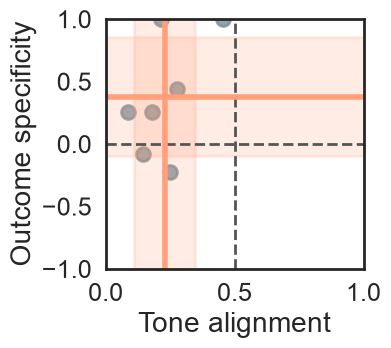

In [15]:
for i, (session, stage) in enumerate(highlight_stages):
    df_local = df_specificity[(df_specificity["Session"] == session) & (df_specificity["Stage"] == stage)]

    fig, ax = plt.subplots(figsize=(4.5, 4))

    avg_trial_relevance = df_local["Tone Alignment"].mean()
    std_trial_relevance = df_local["Tone Alignment"].std()

    avg_specificity = df_local["Outcome Specificity"].mean()
    std_specificity = df_local["Outcome Specificity"].std()

    ax.scatter(df_local["Tone Alignment"], df_local["Outcome Specificity"], s=100, alpha=0.8, color=colors['gray'])

    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 1)
    ax.set_xlabel("Tone alignment")
    ax.set_ylabel("Outcome specificity")

    ax.axhline(0, color=color_lines, linestyle='--', linewidth=2)
    ax.axvline(0.5, color=color_lines, linestyle='--', linewidth=2)

    loc_color = palette_methods_4[i]

    ax.axhline(avg_specificity, color=loc_color, linestyle='-', linewidth=4)
    ax.axvline(avg_trial_relevance, color=loc_color, linestyle='-', linewidth=4)

    if std_specificity > 0:
        ax.fill_between(
            [0, 1], 
            avg_specificity - std_specificity, 
            avg_specificity + std_specificity, 
            color=loc_color, alpha=0.2, label='Outcome Specificity Std'
        )
    if std_trial_relevance > 0:
        ax.axvspan(
            avg_trial_relevance - std_trial_relevance, 
            avg_trial_relevance + std_trial_relevance, 
            color=loc_color, alpha=0.2, label='Tone Alignment Std'
        )

    ax.grid(False)
    fig.tight_layout()

    plt.savefig(path_plots + f"reward_specificity_{session}_{stage}.pdf", dpi=300, bbox_inches='tight')

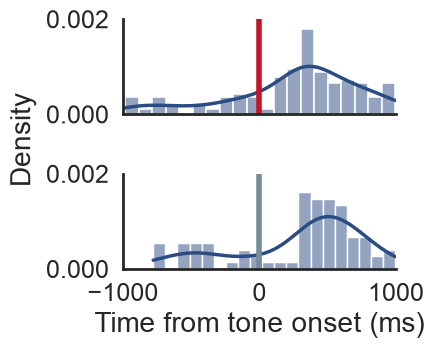

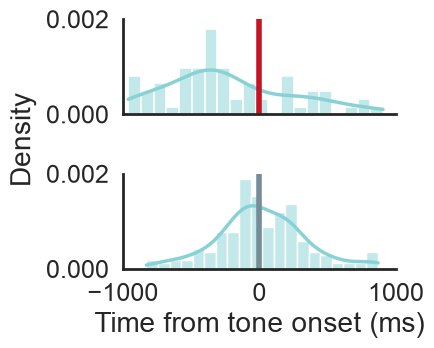

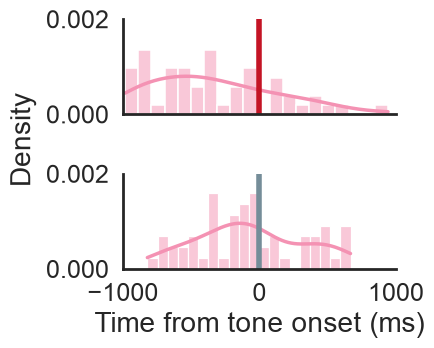

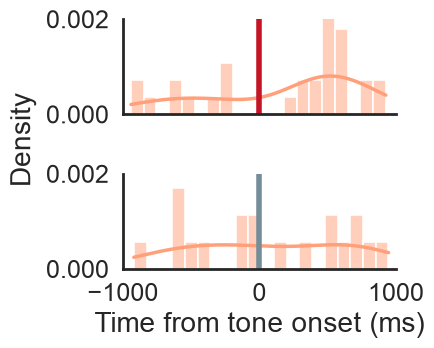

In [16]:
bin_count = 20

for i, (session, stage) in enumerate(highlight_stages):
    fig, ax = plt.subplots(2, 1, sharey=True, sharex=True, figsize=(4.5, 4))

    df_local = df_reward_clean[(df_reward_clean["Session"] == session) & (df_reward_clean["Stage"] == stage)]
    df_local_spec = df_specificity[(df_specificity["Session"] == session) & (df_specificity["Stage"] == stage)]

    df_local_success = df_local[df_local["Event"] == "Success_Signal"].copy()
    df_local_failure = df_local[df_local["Event"] == "Failure"].copy()

    loc_color = palette_methods_4[i]

    sns.histplot(data=df_local_success, x="Time Distance (ms)", bins=bin_count, kde=True, color=loc_color, label='Rewarded', ax=ax[0], stat="density")
    sns.histplot(data=df_local_failure, x="Time Distance (ms)", bins=bin_count, kde=True, color=loc_color, label='Unrewarded', ax=ax[1], stat="density")

    max_height = 0.002

    ax[0].set_ylabel("")
    ax[1].set_ylabel("")
    ax[1].set_xlabel("Time from tone onset (ms)")
    ax[0].set_xlim(-1000, 1000)
    ax[0].set_ylim(0, max_height)

    ax[0].vlines(0, 0, max_height, color=colors['red'], linestyle="solid", linewidth=4)
    ax[1].vlines(0, 0, max_height, color=colors['gray'], linestyle="solid", linewidth=4)

    ax[0].grid(False)    
    ax[1].grid(False)
    sns.despine(left=False)
    fig.tight_layout()

    # Add common Y label
    fig.text(0.00, 0.585, 'Density', va='center', rotation='vertical', fontsize=20)
    fig.tight_layout()

    plt.savefig(path_plots + f"reward_specificity_{session}_{stage}_hist.pdf", dpi=300, bbox_inches='tight')